#Introduction

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##Data Loading

In [ ]:
df = pd.read_csv("online_retail.csv")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


##Data Understanding

In [ ]:
df.shape

(123654, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123654 entries, 0 to 123653
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      123654 non-null  object 
 1   StockCode    123654 non-null  object 
 2   Description  123309 non-null  object 
 3   Quantity     123654 non-null  int64  
 4   InvoiceDate  123653 non-null  object 
 5   Price        123653 non-null  float64
 6   Customer ID  83147 non-null   float64
 7   Country      123653 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 7.5+ MB


In [ ]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,345
Quantity,0
InvoiceDate,1
Price,1
Customer ID,40507
Country,1


In [ ]:
df.describe()

,Quantity,Price,Customer ID
count,123654.000000,123653.000000,83147.000000
mean,8.884848,5.225959,15309.075084
std,303.739986,109.762485,1743.352127
min,-74215.000000,0.000000,12346.000000
25%,1.000000,1.250000,13880.000000
50%,3.000000,2.460000,15235.000000
75%,9.000000,4.240000,16907.000000
max,74215.000000,16888.020000,18283.000000


In [ ]:
df.duplicated().sum()

np.int64(1091)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

##Data Cleaning

In [ ]:
df["Description"] = df["Description"].fillna("Unknown Product")

In [ ]:
df = df.drop(columns=["Customer ID"], errors='ignore')

In [ ]:
df = df[df["Quantity"] > 0]

In [ ]:
df = df[df["Price"] > 0]

In [ ]:
df.shape

(119710, 7)

In [ ]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], dayfirst=True)

In [ ]:
df["Revenue"] = df["Quantity"] * df["Price"]

In [ ]:
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()

In [ ]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Country,Revenue,Year,Month,Day,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,United Kingdom,15.30,2010,12,1,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,United Kingdom,20.34,2010,12,1,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,United Kingdom,22.00,2010,12,1,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,United Kingdom,20.34,2010,12,1,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,United Kingdom,20.34,2010,12,1,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...
123648,546910,20725,LUNCH BAG RED RETROSPOT,4,2011-03-17 19:46:00,1.65,United Kingdom,6.60,2011,3,17,Thursday
123649,546910,22384,LUNCH BAG PINK POLKADOT,4,2011-03-17 19:46:00,1.65,United Kingdom,6.60,2011,3,17,Thursday
123650,546910,22722,SET OF 6 SPICE TINS PANTRY DESIGN,2,2011-03-17 19:46:00,3.95,United Kingdom,7.90,2011,3,17,Thursday
123651,546910,22241,GARLAND WOODEN HAPPY EASTER,4,2011-03-17 19:46:00,1.25,United Kingdom,5.00,2011,3,17,Thursday


## Exploratory Data Analysis (EDA)

In [ ]:
sns.set_style("whitegrid")
sns.set_palette("Set2")

##Monthly Revenue Trend

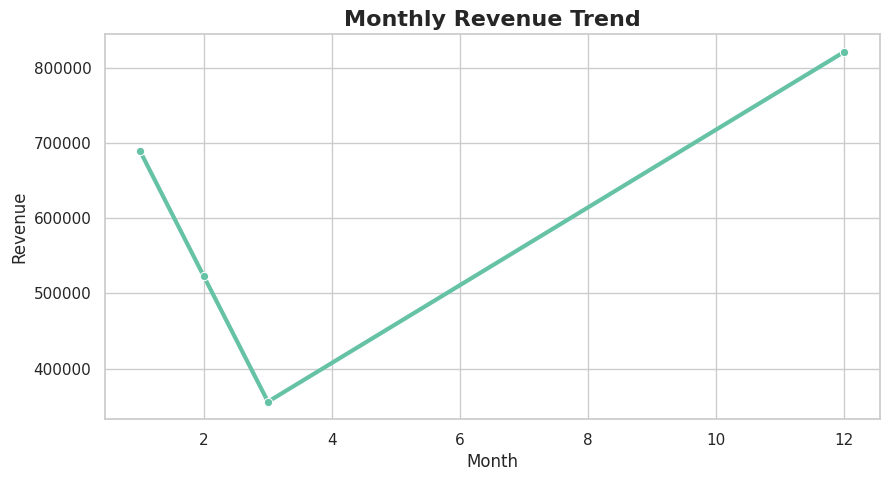

In [ ]:
monthly_revenue = df.groupby("Month")["Revenue"].sum().reset_index()

plt.figure(figsize=(10,5))

sns.lineplot(
    data=monthly_revenue,
    x="Month",
    y="Revenue",
    marker="o",
    linewidth=3
)

plt.title("Monthly Revenue Trend", fontsize=16, weight="bold")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

##Top 10 Products by Revenue

/tmp/ipykernel_242/2917948406.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


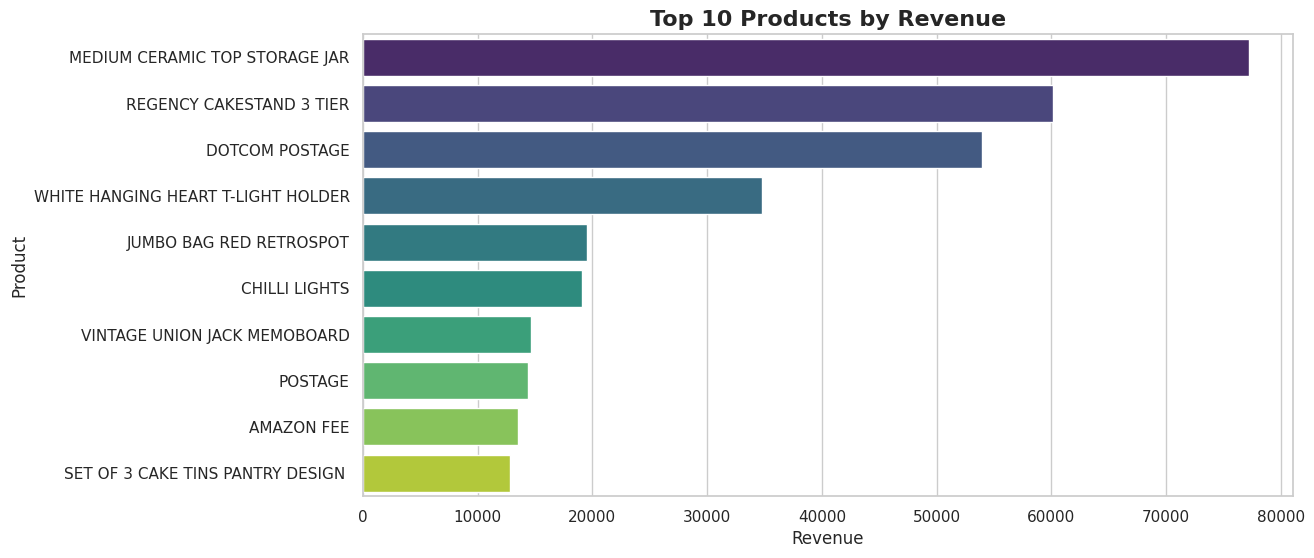

In [ ]:
top_products = (
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    palette="viridis"
)

plt.title("Top 10 Products by Revenue", fontsize=16, weight="bold")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.show()

##Top Countries by Revenue

/tmp/ipykernel_242/915591011.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


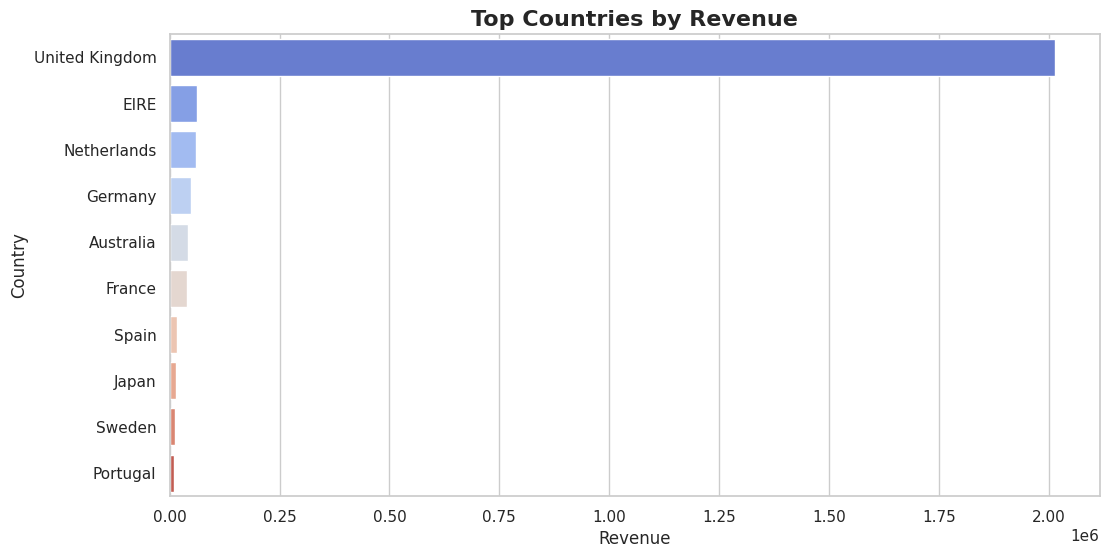

In [ ]:
country_sales = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=country_sales.values,
    y=country_sales.index,
    palette="coolwarm"
)

plt.title("Top Countries by Revenue", fontsize=16, weight="bold")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.show()

##Day of Week Sales Pattern

/tmp/ipykernel_242/1007668464.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


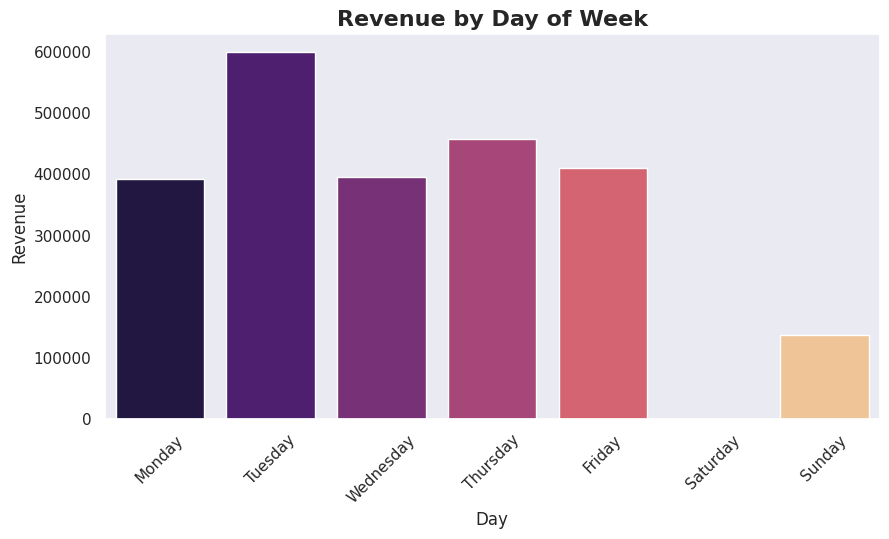

In [ ]:
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

weekday_sales = df.groupby("DayOfWeek")["Revenue"].sum().reindex(order).reset_index()

plt.figure(figsize=(10,5))

sns.barplot(
    data=weekday_sales,
    x="DayOfWeek",
    y="Revenue",
    palette="magma"
)

plt.title("Revenue by Day of Week", fontsize=16, weight="bold")
plt.xlabel("Day")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

##Quantity vs Revenue Relationship

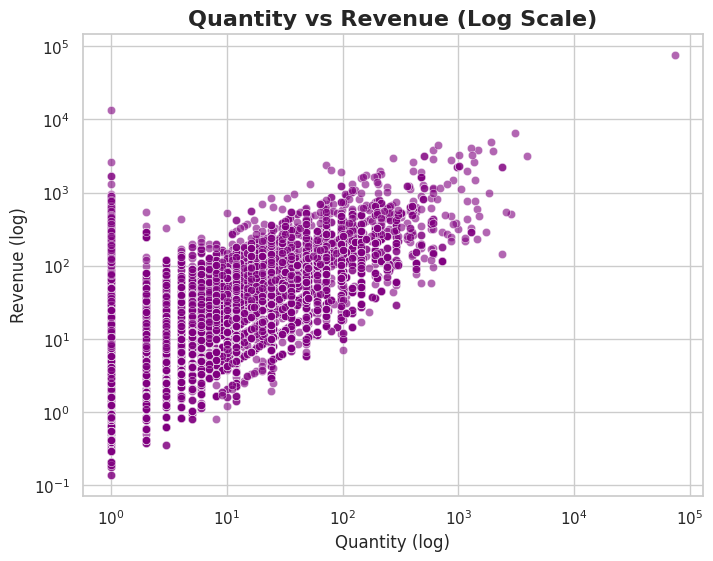

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Quantity",
    y="Revenue",
    color="purple",
    alpha=0.6
)

plt.xscale("log")
plt.yscale("log")

plt.title("Quantity vs Revenue (Log Scale)", fontsize=16, weight="bold")
plt.xlabel("Quantity (log)")
plt.ylabel("Revenue (log)")

plt.show()

##Correlation Heatmap

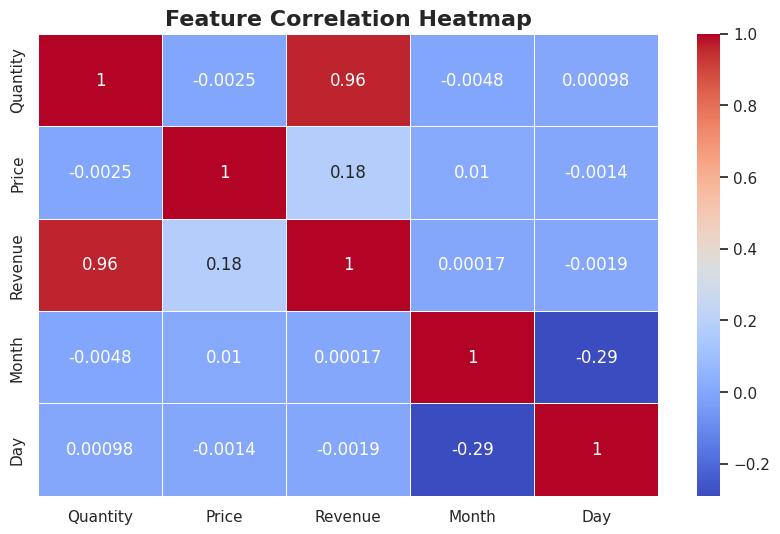

In [ ]:
plt.figure(figsize=(10,6))

corr = df[["Quantity","Price","Revenue","Month","Day"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap", fontsize=16, weight="bold")

plt.show()

##Sales Seasonality Heatmap (Month vs Year)

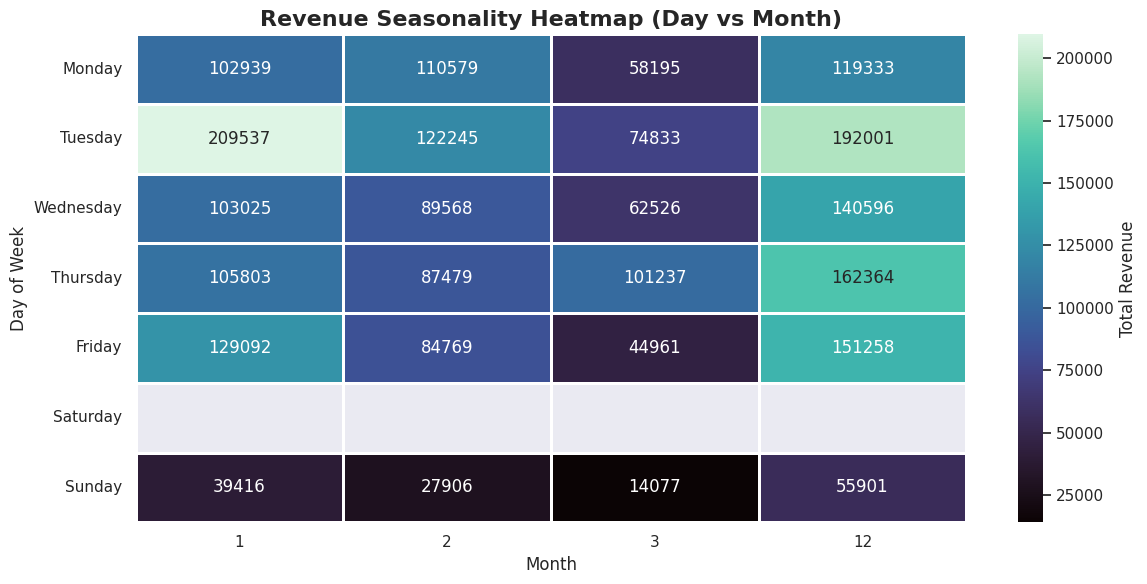

In [ ]:
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

seasonality = df.pivot_table(
    values="Revenue",
    index="DayOfWeek",
    columns="Month",
    aggfunc="sum"
).reindex(order)

plt.figure(figsize=(12,6))

sns.set_theme(style="dark")   # Dark background theme

sns.heatmap(
    seasonality,
    cmap="mako",              # Completely different color palette
    annot=True,
    fmt=".0f",
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Total Revenue"}
)

plt.title("Revenue Seasonality Heatmap (Day vs Month)", fontsize=16, weight="bold")
plt.xlabel("Month")
plt.ylabel("Day of Week")

plt.tight_layout()
plt.show()

In [ ]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Country', 'Revenue', 'Year', 'Month', 'Day', 'DayOfWeek'],
      dtype='object')

In [ ]:
df.drop(["Invoice","StockCode","Description","Country"], axis=1, inplace=True)

In [ ]:
df

,Quantity,InvoiceDate,Price,Revenue,Year,Month,Day,DayOfWeek
0,6,2010-12-01 08:26:00,2.55,15.30,2010,12,1,Wednesday
1,6,2010-12-01 08:26:00,3.39,20.34,2010,12,1,Wednesday
2,8,2010-12-01 08:26:00,2.75,22.00,2010,12,1,Wednesday
3,6,2010-12-01 08:26:00,3.39,20.34,2010,12,1,Wednesday
4,6,2010-12-01 08:26:00,3.39,20.34,2010,12,1,Wednesday
...,...,...,...,...,...,...,...,...
123648,4,2011-03-17 19:46:00,1.65,6.60,2011,3,17,Thursday
123649,4,2011-03-17 19:46:00,1.65,6.60,2011,3,17,Thursday
123650,2,2011-03-17 19:46:00,3.95,7.90,2011,3,17,Thursday
123651,4,2011-03-17 19:46:00,1.25,5.00,2011,3,17,Thursday


In [ ]:
daily_sales = df.groupby("InvoiceDate")["Revenue"].sum().reset_index()

daily_sales.head()

,InvoiceDate,Revenue
0,2010-12-01 08:26:00,139.12
1,2010-12-01 08:28:00,22.20
2,2010-12-01 08:34:00,348.78
3,2010-12-01 08:35:00,17.85
4,2010-12-01 08:45:00,855.86


In [ ]:
daily_sales["InvoiceDate"] = pd.to_datetime(daily_sales["InvoiceDate"])

daily_sales.set_index("InvoiceDate", inplace=True)

daily_sales.head()

,Revenue
InvoiceDate,
2010-12-01 08:26:00,139.12
2010-12-01 08:28:00,22.20
2010-12-01 08:34:00,348.78
2010-12-01 08:35:00,17.85
2010-12-01 08:45:00,855.86


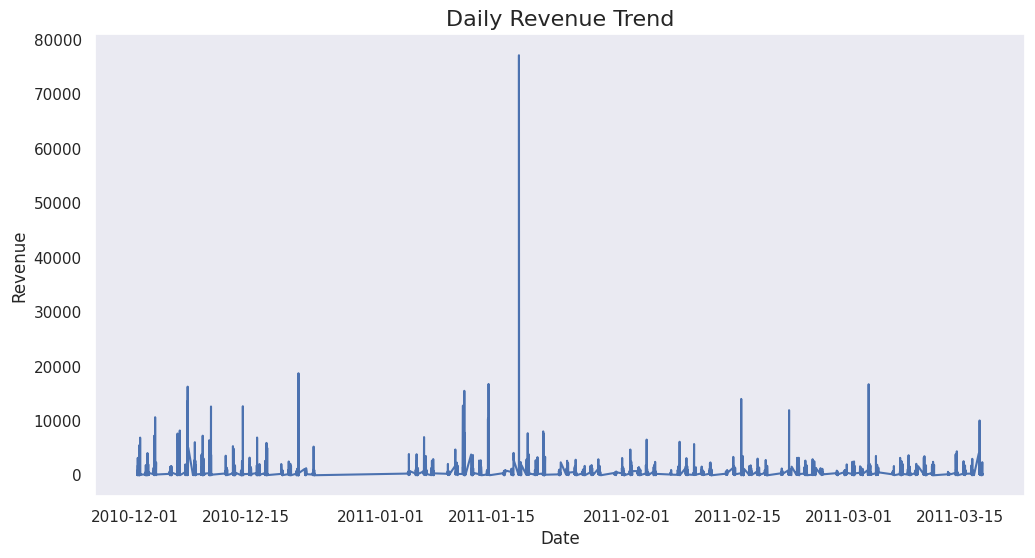

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(daily_sales["Revenue"])

plt.title("Daily Revenue Trend", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.show()

In [ ]:
daily_sales = daily_sales.asfreq("D")
daily_sales["Revenue"] = daily_sales["Revenue"].fillna(0)

In [ ]:
train_size = int(len(daily_sales) * 0.8)

train = daily_sales.iloc[:train_size]
test = daily_sales.iloc[train_size:]

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train["Revenue"], order=(1,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test))

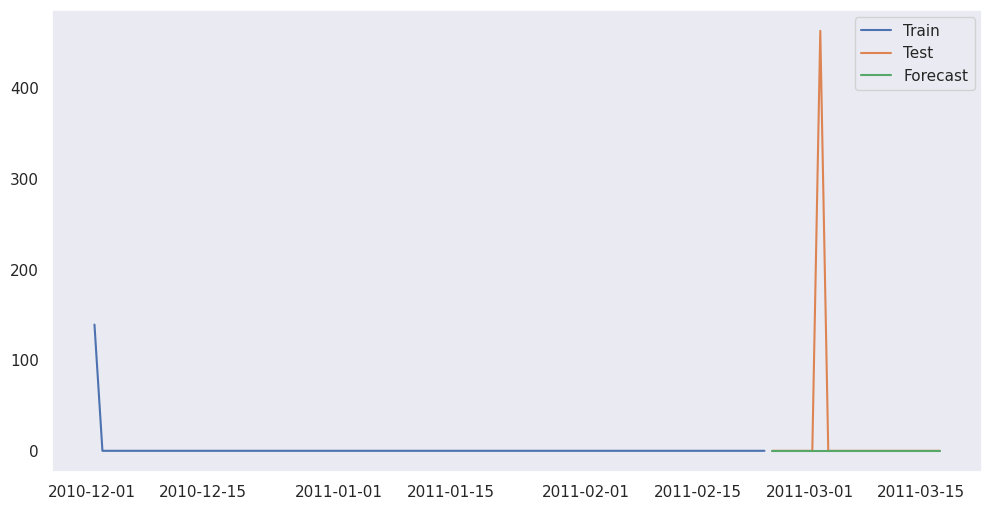

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train["Revenue"], label="Train")
plt.plot(test.index, test["Revenue"], label="Test")
plt.plot(test.index, forecast, label="Forecast")

plt.legend()
plt.show()